100%|██████████| 481k/481k [00:00<00:00, 73.7MB/s]

Extracting files...
Columns in dataset:
 Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'Target'],
      dtype='object')


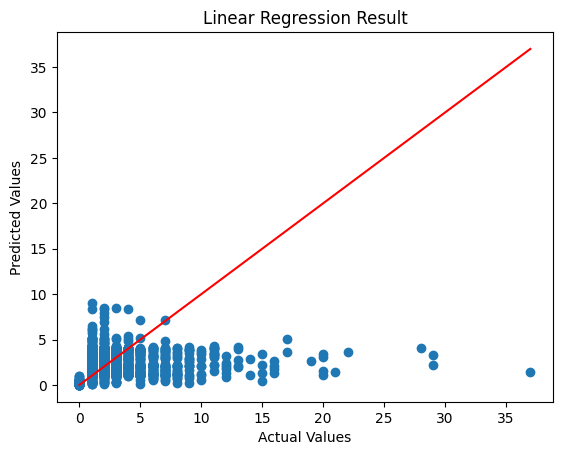

Coefficients: [ 2.16970390e-03  1.23759437e-05 -3.25001357e-03  1.00341100e-05
  7.53216814e-03  1.06375779e-02]
Intercept: 0.0806872970072059
MSE: 2.1720935353120674
R2 Score: 0.308578082610242


In [1]:
# Install dependency
!pip install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Download dataset
path = kagglehub.dataset_download("krantiswalke/bankfullcsv")

# Load dataset
df = pd.read_csv(path + "/bank-full.csv", sep=',')

# Show column names (for verification)
print("Columns in dataset:\n", df.columns)

# Select only numeric columns automatically
numeric_df = df.select_dtypes(include=np.number)

# Features and target
X = numeric_df.iloc[:, :-1]
y = numeric_df.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Visualization
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression Result")
plt.show()

# Model parameters
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))